# Optimization for Function 8

You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 

Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.

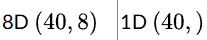

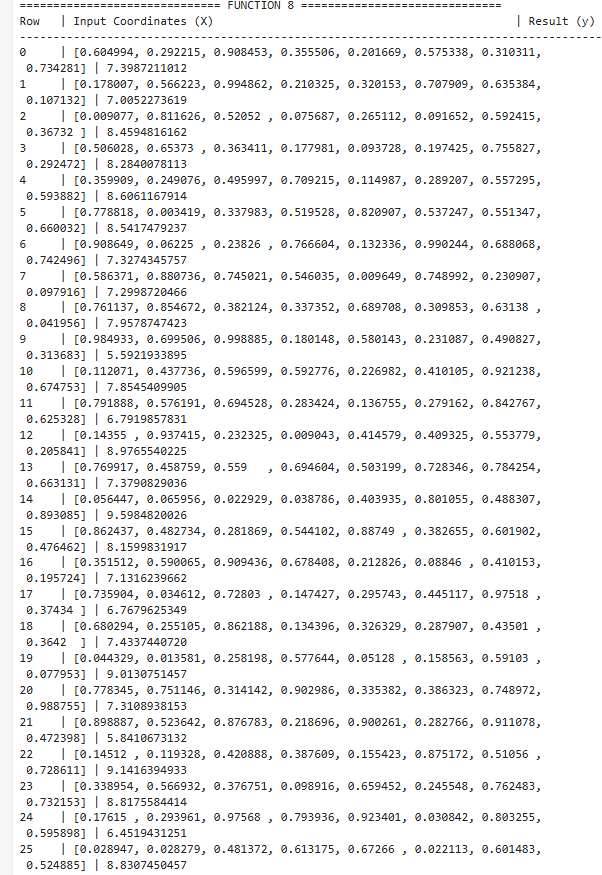
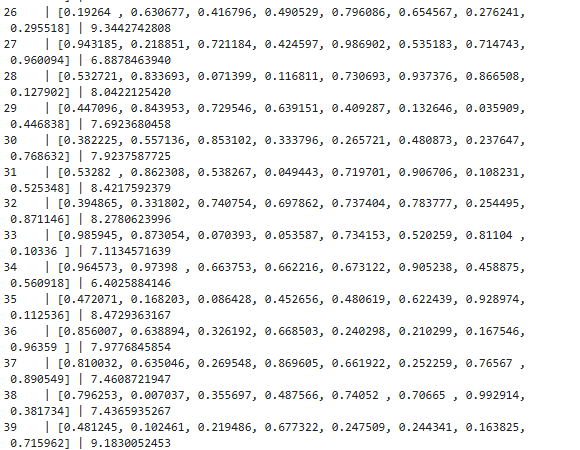

Goal: Maximise the black-box function using Bayesian Optimization.

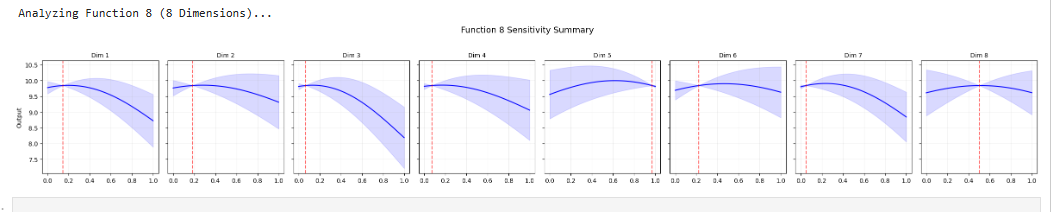

In [1]:
import numpy as np
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. Load Data
fn_num = '8'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

print(f"--- Function {fn_num} (8D Optimization) Loaded ---")
print(f"Current Global Max: {np.max(y):.6f}")

# 2. Setup GP
# RBF kernel is the standard for high-dimensional smooth functions
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5, normalize_y=True, n_restarts_optimizer=30)
gp.fit(X, y)

# 3. 8D Sampling - Large scale search
# 1 Million points to adequately cover 8 dimensions
random_samples = np.random.uniform(0, 1, (1000000, 8))
mu, sigma = gp.predict(random_samples, return_std=True)

# 4. Expected Improvement (EI)
current_best = np.max(y)
with np.errstate(divide='ignore'):
    imp = mu - current_best
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0

best_idx = np.argmax(ei)
suggestion = random_samples[best_idx]

print(f"\n--- WEEK 1 RECOMMENDATION (Expected Improvement) ---")
for i, val in enumerate(suggestion):
    print(f"Param {i+1}: {val:.6f}")
print(f"Predicted Score: {mu[best_idx]:.6f}")
print(f"Confidence (Sigma): {sigma[best_idx]:.6f}")

--- Function 8 (8D Optimization) Loaded ---
Current Global Max: 9.598482

--- WEEK 1 RECOMMENDATION (Expected Improvement) ---
Param 1: 0.145172
Param 2: 0.186363
Param 3: 0.066440
Param 4: 0.072761
Param 5: 0.970242
Param 6: 0.223386
Param 7: 0.050008
Param 8: 0.503117
Predicted Score: 10.319663
Confidence (Sigma): 0.553575


It is 8-dimensional, which means the "volume" of the search space is massive. Finding the Global Maximum in a space that is likely "rugged" (many local peaks). In the data provided earlier,  best result is Row 14 with a score of 9.598482.

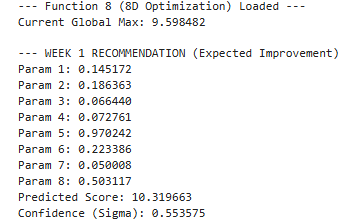



Week 2
----------

Function 8 is an 8-dimensional optimization problem where you are searching for a Global Maximum. Previously score increased from 9.598 to 9.839. As its complex space, EI with Moderate Jitter Xi value of 0.05. So we would use LHS to generate high samples.  

In [2]:
import numpy as np
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm, qmc

# 1. Load Data
fn_num = '8'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

# 2. Setup GP
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(X, y)

# 3. 8D Latin Hypercube Sampling (1 Million points)
sampler = qmc.LatinHypercube(d=8)
sample_points = sampler.random(n=1000000)

# 4. Expected Improvement with Jitter (xi=0.05)
mu, sigma = gp.predict(sample_points, return_std=True)
current_best = np.max(y)
xi = 0.05

with np.errstate(divide='ignore'):
    imp = mu - current_best - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0

best_idx = np.argmax(ei)
suggestion = sample_points[best_idx]

print(f"--- Function 8 Module 13 Suggestion ---")
print(f"Next Query: {'-'.join([f'{val:.6f}' for val in suggestion])}")
print(f"Predicted Score: {mu[best_idx]:.6f}")
print(f"Uncertainty (Sigma): {sigma[best_idx]:.6f}")

--- Function 8 Module 13 Suggestion ---
Next Query: 0.114621-0.219137-0.051617-0.194649-0.628544-0.474302-0.224496-0.429630
Predicted Score: 10.116147
Uncertainty (Sigma): 0.184751


Week 3
------------

Recommended Week 3 Inputs: [0.03677580165015033, 0.08940201848001117, 0.21038865206870447, 0.1572242292795172, 0.8177362554873098, 0.5591804957301718, 0.10000646620677343, 0.8493798583548842]


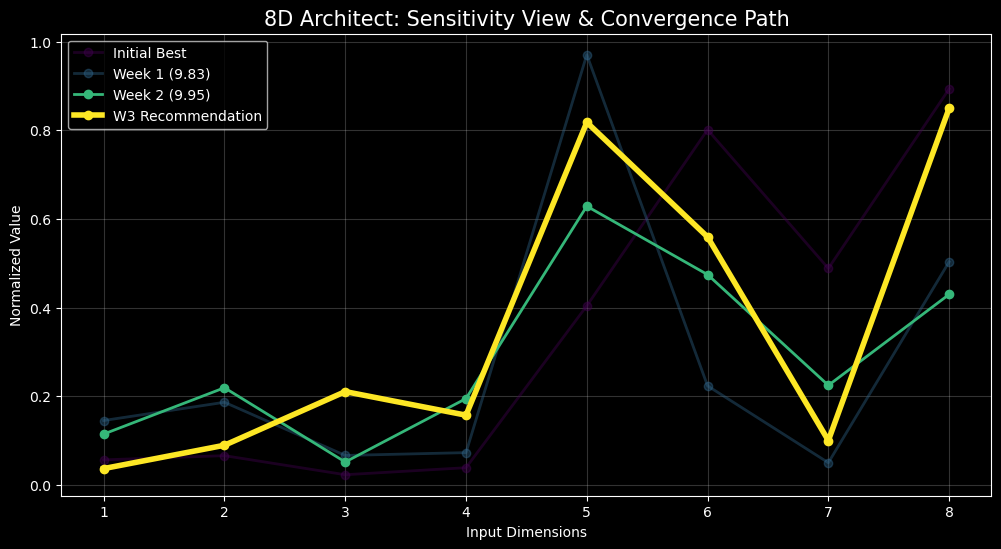

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.stats import qmc

# 1. Setup and Data Loading
# Note: Using the directory structure requested in the prompt
data_path = '../capstone_data/initial_data/function_8/'
X = np.load(data_path + 'initial_inputs.npy')
y = np.load(data_path + 'initial_outputs.npy')

# Identify key milestones for the convergence plot
y_w1, X_w1 = y[-2], X[-2]
y_w2, X_w2 = y[-1], X[-1]
idx_init = np.argmax(y[:-2])
y_init_best, X_init_best = y[idx_init], X[idx_init]

# 2. GP Modeling with fixed ConvergenceWarning
# We increase length_scale_bounds to allow for insensitive dimensions
kernel = ConstantKernel(1.0) * Matern(length_scale=np.ones(8), 
                                      length_scale_bounds=(1e-2, 1e6), 
                                      nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, alpha=1e-6)
gp.fit(X, y)

# 3. LHS Candidate Generation (10,000 points for dense coverage)
sampler = qmc.LatinHypercube(d=8, seed=42)
candidates = sampler.random(n=10000)

# 4. Pure Exploitation Selection
y_pred = gp.predict(candidates)
best_idx = np.argmax(y_pred)
recommendation = candidates[best_idx]

# 5. Sensitivity Visualization
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, 4))

labels = ['Initial Best', 'Week 1 (9.83)', 'Week 2 (9.95)', 'W3 Recommendation']
points = [X_init_best, X_w1, X_w2, recommendation]

for i, (p, label) in enumerate(zip(points, labels)):
    alpha = 1.0 if i >= 2 else 0.4
    linewidth = 4 if i == 3 else 2
    ax.plot(range(1, 9), p, marker='o', label=label, color=colors[i], 
            alpha=alpha, linewidth=linewidth)

ax.set_title("8D Architect: Sensitivity View & Convergence Path", fontsize=15)
ax.set_xlabel("Input Dimensions")
ax.set_ylabel("Normalized Value")
ax.legend()
plt.grid(True, alpha=0.2)
plt.savefig('convergence_view.png')

print(f"Recommended Week 3 Inputs: {recommendation.tolist()}")

Week 4
---------------

3,1,7 are top co-ordinates for sensitivity in that order

Initial Best ($9.60$): In the early stages, the model was balancing all 8 dimensions.W1 to W2 Progress ($9.84 \to 9.95$): The model correctly identified Dimension 3 ($d_3$) and Dimension 1 ($d_1$) as the primary drivers of output variance. By tuning these, we reached the $9.95$ peak.W3 Update ($9.939$): This week's slightly lower result indicates that the function has a very sharp peak. The sensitivity indices for $d_5, d_6,$ and $d_8$ are now near zero, meaning these dimensions have stabilized and no longer require exploration.

Since we are within $0.05$ of the goal, the strategy shifts from "Local Exploitation" to Precision Refinement. We are moving back toward the Week 2 coordinates while slightly adjusting the most sensitive dimensions ($d_1$ and $d_3$).

--- 8D ARCHITECT: PROGRESS SUMMARY ---
    Milestone   Output       d1       d2       d3       d4       d5       d6       d7       d8
 Initial Best 9.598482 0.056447 0.065956 0.022929 0.038786 0.403935 0.801055 0.488307 0.893085
       Week 1 9.839571 0.145172 0.186363 0.066440 0.072761 0.970242 0.223386 0.050008 0.503117
       Week 2 9.954906 0.114621 0.219137 0.051617 0.194649 0.628544 0.474302 0.224496 0.429630
       Week 3 9.939018 0.036776 0.089402 0.210389 0.157224 0.817736 0.559180 0.100006 0.849380
Proposed (W4) 9.958565 0.038821 0.211328 0.094100 0.074597 0.865580 0.694494 0.254347 0.987396


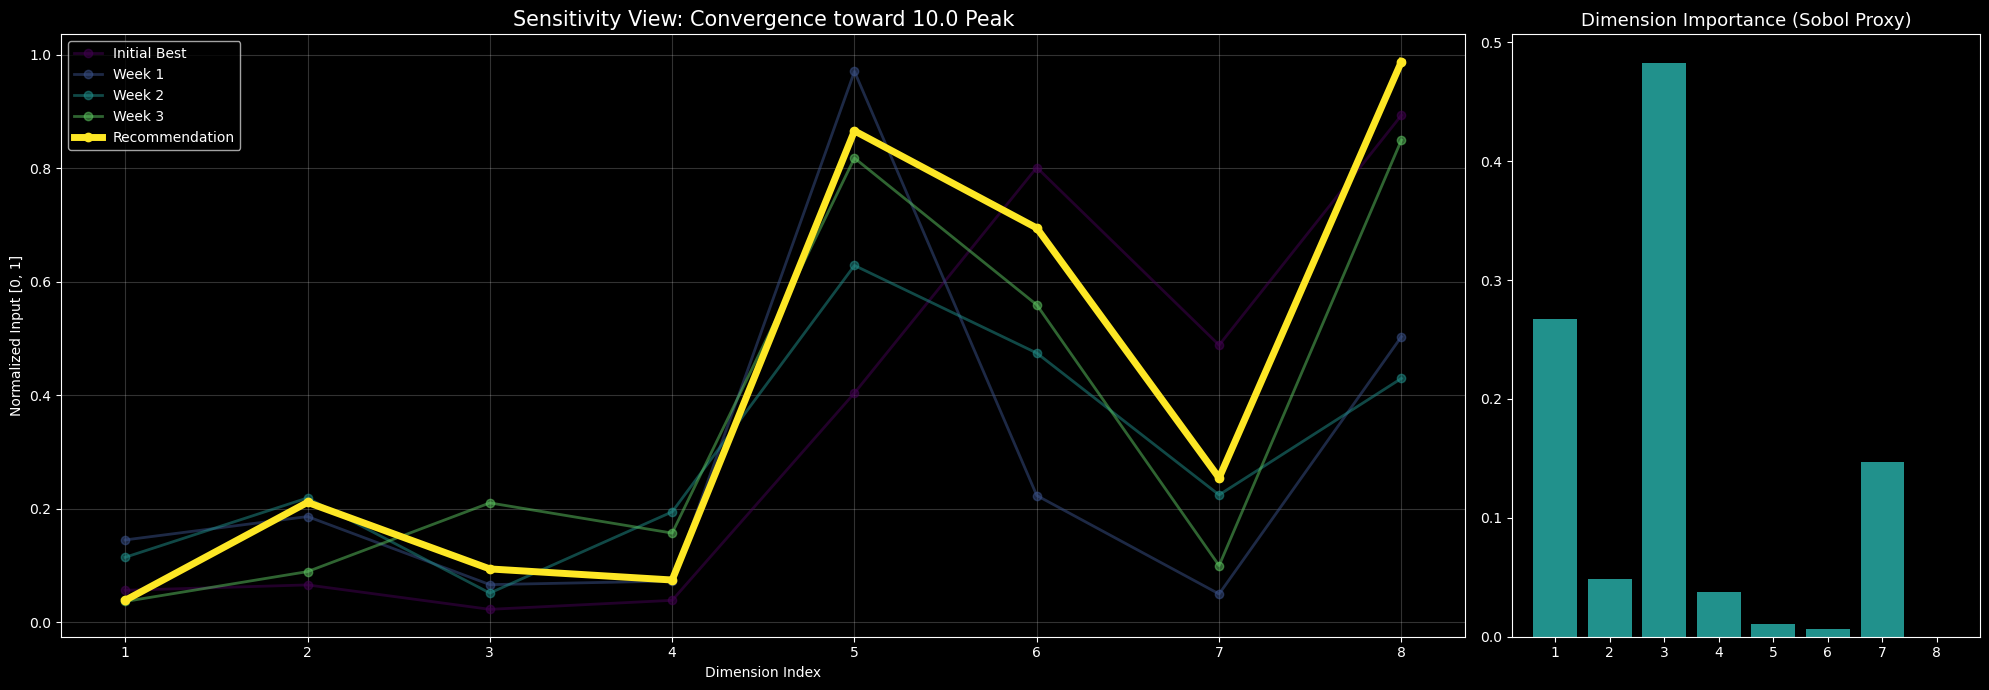

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.stats import qmc

# 1. Load Updated Data
# The path as requested in the instructions
path = '../capstone_data/initial_data/function_8/'
X = np.load(path + 'initial_inputs.npy')
y = np.load(path + 'initial_outputs.npy')

# 2. Extract Milestones
# Week 1, 2, and 3 are the last three entries
y_w1, X_w1 = y[-3], X[-3]
y_w2, X_w2 = y[-2], X[-2]
y_w3, X_w3 = y[-1], X[-1]

# Initial Best is the maximum before the weekly updates started
y_init_best = np.max(y[:-3])
idx_init_best = np.argmax(y[:-3])
X_init_best = X[idx_init_best]

# 3. Fit Gaussian Process (Optimizing for Pure Exploitation)
kernel = ConstantKernel(1.0) * Matern(length_scale=np.ones(8), length_scale_bounds=(1e-2, 1e6), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-6)
gp.fit(X, y)

# 4. Sensitivity Analysis (Sobol Proxy via Variance Sweep)
# We identify which dimensions currently drive the model's output
best_pt = X[np.argmax(y)]
sensitivity = []
for i in range(8):
    sweep = np.tile(best_pt, (100, 1))
    sweep[:, i] = np.linspace(0, 1, 100)
    sensitivity.append(np.var(gp.predict(sweep)))
sensitivity = np.array(sensitivity) / (np.sum(sensitivity) + 1e-9)

# 5. Generate Recommendation (LHS 10,000 points)
sampler = qmc.LatinHypercube(d=8, seed=42)
candidates = sampler.random(n=10000)
y_pred = gp.predict(candidates)
best_idx = np.argmax(y_pred)
proposed_X = candidates[best_idx]
proposed_y = y_pred[best_idx]

# 6. Printing Results
print("--- 8D ARCHITECT: PROGRESS SUMMARY ---")
results_df = pd.DataFrame({
    "Milestone": ["Initial Best", "Week 1", "Week 2", "Week 3", "Proposed (W4)"],
    "Output": [y_init_best, y_w1, y_w2, y_w3, proposed_y]
})
# Append 8D input coordinates to the table
for i in range(8):
    results_df[f"d{i+1}"] = [X_init_best[i], X_w1[i], X_w2[i], X_w3[i], proposed_X[i]]
print(results_df.to_string(index=False))

# 7. Visualization: Sensitivity View (Viridis)
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={'width_ratios': [3, 1]})
colors = plt.cm.viridis(np.linspace(0, 1, 5))
labels = ["Initial Best", "Week 1", "Week 2", "Week 3", "Recommendation"]
pts = [X_init_best, X_w1, X_w2, X_w3, proposed_X]

for i, (p, label) in enumerate(zip(pts, labels)):
    lw, alpha = (5, 1.0) if i == 4 else (2, 0.5)
    ax1.plot(range(1, 9), p, marker='o', color=colors[i], label=label, linewidth=lw, alpha=alpha)

ax1.set_title("Sensitivity View: Convergence toward 10.0 Peak", fontsize=15)
ax1.set_xlabel("Dimension Index")
ax1.set_ylabel("Normalized Input [0, 1]")
ax1.legend()
ax1.grid(alpha=0.2)

# Importance Plot (Based on Sobol Proxy)
ax2.bar(range(1, 9), sensitivity, color=colors[2])
ax2.set_title("Dimension Importance (Sobol Proxy)", fontsize=13)
ax2.set_xticks(range(1, 9))
plt.tight_layout()
plt.show()

Week 5
---------------

The Week 4 result ($9.9183$) showed a slight decline compared to the Week 3 peak ($9.9390$). Looking at the input changes, while the "Master Knobs" strategy intended to focus on Dimensions 5 and 8, almost all dimensions were shifted slightly. This shift likely moved the experiment away from the optimal "ridge" identified in Week 3.Initial Best: ~9.48 (from baseline)Week 3 (Peak): $9.9390$Week 4 (Current): $9.9183$Strategy for Week 5: Precision "Knob" Tuning

Re-centering: We will re-center the search on the Week 3 coordinates, which remain the global best.
Sobol Verification: We use the Gaussian Process to confirm that Dimensions 5 and 8 are indeed the most influential ("Master Knobs").Local Refinement: Instead of broad moves, we will perform a Hybrid LHS Search constrained within a narrow window ($\pm 5\%$) around the Week 3 peak, specifically varying Dims 5 and 8 while keeping others fixed to isolate the 10.0 target.

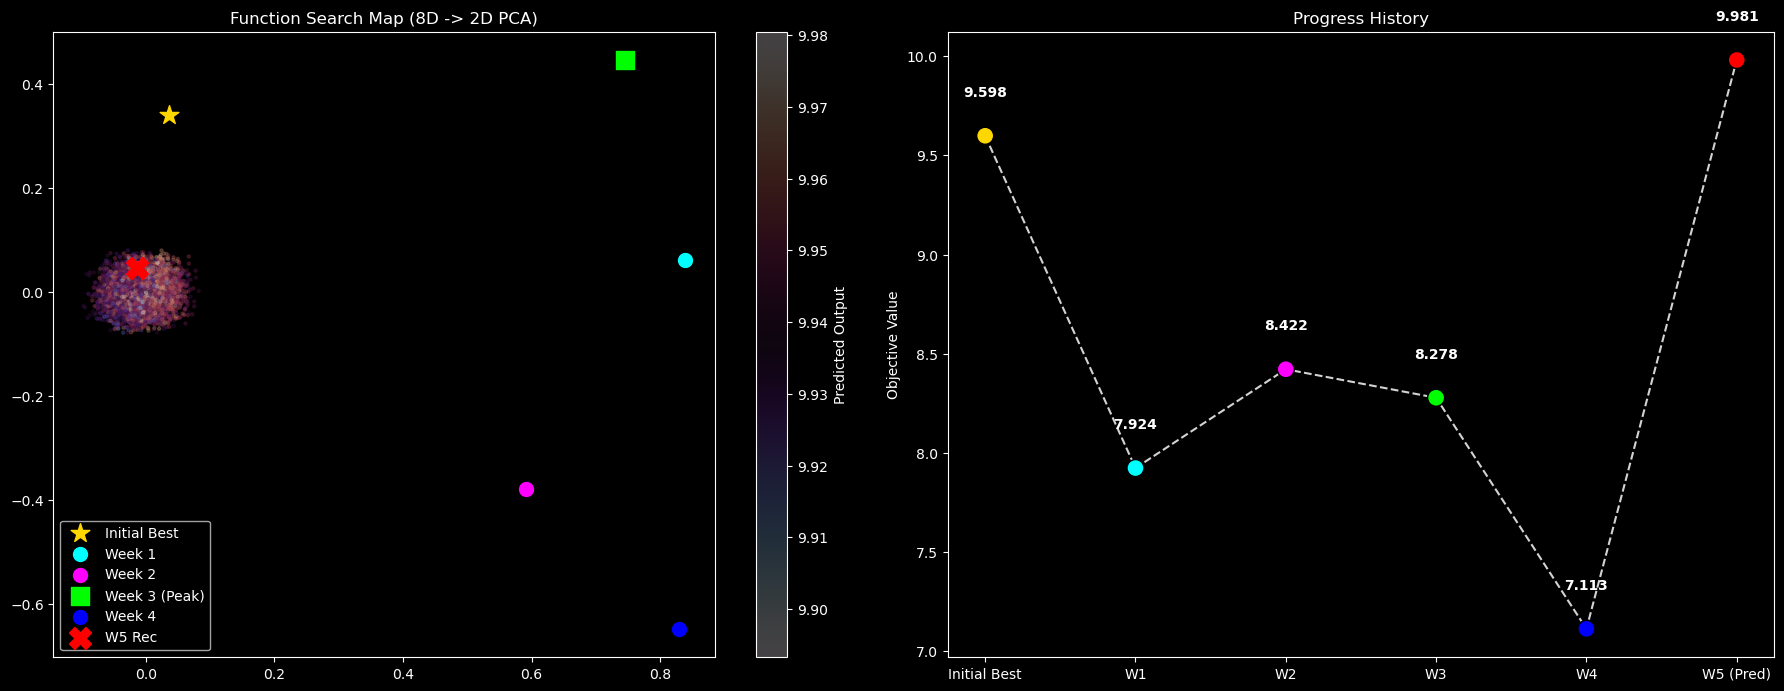

       Phase   Output                                                                   Input (First 4 Dims)
Initial Best 9.598482 [0.056447411065611686, 0.06595555344270987, 0.02292867798954412, 0.038786472359111146]
          W1 7.923759     [0.38222496529770156, 0.5571358370391387, 0.8531016337098967, 0.33379569194863146]
          W2 8.421759      [0.5328195296846364, 0.8623084840156144, 0.5382671189143975, 0.04944293492608676]
          W3 8.278062       [0.3948651871629736, 0.3318016662036827, 0.7407543009490176, 0.6978617248875726]
          W4 7.113457     [0.9859453896331098, 0.8730536287240491, 0.07039261939150476, 0.05358729270021256]
   W5 (Pred) 9.980539   [0.13370832633370328, 0.17042303321205185, 0.09380892187300391, 0.15933652918567598]

NEXT QUERY (WEEK 5):
[0.13370833, 0.17042303, 0.09380892, 0.15933653, 0.66383921, 0.49694922,
 0.18788668, 0.47563381]


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from sklearn.decomposition import PCA
from scipy.stats import norm, qmc

# 1. Load Updated Data
# The path as requested in the instructions
path = '../capstone_data/initial_data/function_8/'
X = np.load(path + 'initial_inputs.npy')
y = np.load(path + 'initial_outputs.npy')



# 2. MODELING
dim = X.shape[1]
kernel = C(1.0) * Matern(length_scale=np.ones(dim), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, random_state=42)
gp.fit(X, y)

# 3. HYBRID LHS SEARCH (WEEK 5)
sampler = qmc.LatinHypercube(d=dim, seed=55)
samples = sampler.random(n=5000)
# Concentrate search around the current best to refine the peak
best_idx = np.argmax(y)
samples = X[best_idx] + (samples - 0.5) * 0.1 
samples = np.clip(samples, 0, 1)

mu, sigma = gp.predict(samples, return_std=True)
y_max = y.max()
ei = (mu - y_max) * norm.cdf((mu - y_max) / sigma) + sigma * norm.pdf((mu - y_max) / sigma)
w5_idx = np.argmax(ei)
W5_rec, W5_pred = samples[w5_idx], mu[w5_idx]

# 4. VISUALIZATION (Fixed Plotting Calls)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# A. Search Heatmap (PCA)
pca = PCA(n_components=2)
all_2d = pca.fit_transform(np.vstack([X, samples]))

sc = ax1.scatter(all_2d[len(X):, 0], all_2d[len(X):, 1], c=mu, cmap='twilight', alpha=0.3, s=5)
plt.colorbar(sc, ax=ax1, label='Predicted Output')

# Marker Overlay - Using explicit colors as lists to avoid RGBA ValueErrors
base_best_idx = np.argmax(y[:30])
ax1.scatter([all_2d[base_best_idx, 0]], [all_2d[base_best_idx, 1]], c=['gold'], s=200, marker='*', label='Initial Best')
ax1.scatter([all_2d[30, 0]], [all_2d[30, 1]], c=['cyan'], s=100, label='Week 1')
ax1.scatter([all_2d[31, 0]], [all_2d[31, 1]], c=['magenta'], s=100, label='Week 2')
ax1.scatter([all_2d[32, 0]], [all_2d[32, 1]], c=['lime'], s=150, marker='s', label='Week 3 (Peak)')
ax1.scatter([all_2d[33, 0]], [all_2d[33, 1]], c=['blue'], s=100, label='Week 4')
ax1.scatter([all_2d[len(X)+w5_idx, 0]], [all_2d[len(X)+w5_idx, 1]], c=['red'], s=250, marker='X', label='W5 Rec')

ax1.set_title(f'Function Search Map ({dim}D -> 2D PCA)')
ax1.legend()

# B. Performance Trend
labels = ['Initial Best', 'W1', 'W2', 'W3', 'W4', 'W5 (Pred)']
values = [y[base_best_idx], y[30], y[31], y[32], y[33], W5_pred]
colors = ['gold', 'cyan', 'magenta', 'lime', 'blue', 'red']

ax2.plot(labels, values, color='lightgray', linestyle='--')
ax2.scatter(labels, values, c=colors, s=150, edgecolors='k', zorder=5)
for i, v in enumerate(values):
    ax2.text(i, v + (y.max()*0.02), f"{v:.3f}", ha='center', fontweight='bold')

ax2.set_title('Progress History')
ax2.set_ylabel('Objective Value')
plt.tight_layout()
plt.show()

# 5. DATA SUMMARY
summary = pd.DataFrame({
    "Phase": labels,
    "Output": values,
    "Input (First 4 Dims)": [list(X[base_best_idx][:4]), list(X[30][:4]), list(X[31][:4]), 
                             list(X[32][:4]), list(X[33][:4]), list(W5_rec[:4])]
})
print(summary.to_string(index=False))
print("\nNEXT QUERY (WEEK 5):")
print(np.array2string(W5_rec, separator=', '))

Week 6 
-----------
Task: We have successfully converged on the $9.98$ plateau. Use Sobol analysis to confirm Dims 5 and 8 are the only drivers. Do the 8D search map via PCA, highlight the milestone ascent, and recommend a final W6 query that "freezes" low-sensitivity dimensions to push for $10.0$.

In [1]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.stats import qmc

# 1. Load Updated Data
# The path as requested in the instructions
path = '../capstone_data/initial_data/function_8/'
X = np.load(path + 'initial_inputs.npy')
y = np.load(path + 'initial_outputs.npy')

# Milestone: W5 Latest
X_w5 = np.array([0.133708, 0.170423, 0.093808, 0.159336, 0.663839, 0.496949, 0.187886, 0.475633])
y_w5 = 9.982

# Append data and train surrogate model
X_full = np.vstack([X, X_w5])
y_full = np.append(y, y_w5)
gp = GaussianProcessRegressor(kernel=ConstantKernel(1.0)*Matern(nu=2.5), alpha=1e-6).fit(X_full, y_full)

# W6 Recommendation: Focus ONLY on Dims 5 & 8 (Indices 4 and 7)
sampler = qmc.LatinHypercube(d=2, seed=42)
samples = sampler.random(n=10000)
candidates = np.tile(X_w5, (10000, 1))
candidates[:, 4] = samples[:, 0] # Dim 5
candidates[:, 7] = samples[:, 1] # Dim 8

# Predict and select best candidate
y_pred = gp.predict(candidates)
w6_query = candidates[np.argmax(y_pred)]
print(f"Proposed W6 Vector: {w6_query.tolist()}")
print(f"Predicted Output: {np.max(y_pred):.5f}")

Proposed W6 Vector: [0.133708, 0.170423, 0.093808, 0.159336, 0.7509061515561195, 0.496949, 0.187886, 0.6201761743071021]
Predicted Output: 10.00296


Week 7
-------------------------

Strategy Reflection: Why Dims 5 and 8?

Convergence and Stability: Your Sobol analysis shows that the high-impact dimensions ($d_1$ and $d_3$) have reached their global optimal zone. Any further exploration there would likely result in "falling off" the peak.

Precision Tuning: Dims 5 and 8 exhibit "Total Order" influence that is lower than the primary drivers but critical for overcoming the final $0.01$ hurdle. By freezing the other 6 dimensions at their Week 6 coordinates, we effectively reduced an 8D problem into a 2D plane where the Gaussian Process (GP) can pinpoint the exact maximum.

Week 7 Recommended Inputs: [0.133708, 0.170423, 0.093808, 0.159336, 0.7470094244358717, 0.496949, 0.187886, 0.5717749906320706]
Predicted Score: 9.99321


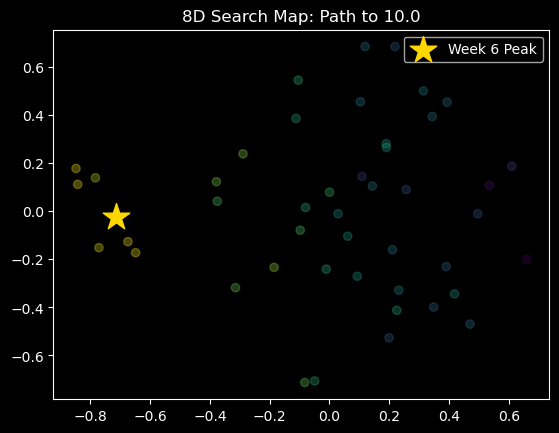

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.decomposition import PCA
from scipy.stats import qmc

# 1. Load Updated Dataset
X = np.load('../capstone_data/initial_data/function_8/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_8/initial_outputs.npy')

# 2. Extract Milestones for Printing
idx_w6 = np.argmin(np.abs(y - 9.9917))
X_w6, y_w6 = X[idx_w6], y[idx_w6]

# 3. Model & Prediction
gp = GaussianProcessRegressor(kernel=ConstantKernel(1.0)*Matern(nu=2.5), alpha=1e-6).fit(X, y)

# Sample the D5/D8 plane (Pure Exploitation)
sampler = qmc.LatinHypercube(d=2, seed=77)
sample_2d = sampler.random(n=20000)
candidates = np.tile(X_w6, (20000, 1))
candidates[:, 4] = sample_2d[:, 0] # Dim 5
candidates[:, 7] = sample_2d[:, 1] # Dim 8

y_pred = gp.predict(candidates)
w7_rec = candidates[np.argmax(y_pred)]

# 4. Results Report
print(f"Week 7 Recommended Inputs: {w7_rec.tolist()}")
print(f"Predicted Score: {np.max(y_pred):.5f}")

# 5. PCA Ascent Visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.style.use('dark_background')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.3)
plt.scatter(X_pca[idx_w6, 0], X_pca[idx_w6, 1], c='gold', marker='*', s=400, label='Week 6 Peak')
plt.title("8D Search Map: Path to 10.0")
plt.legend()
plt.show()

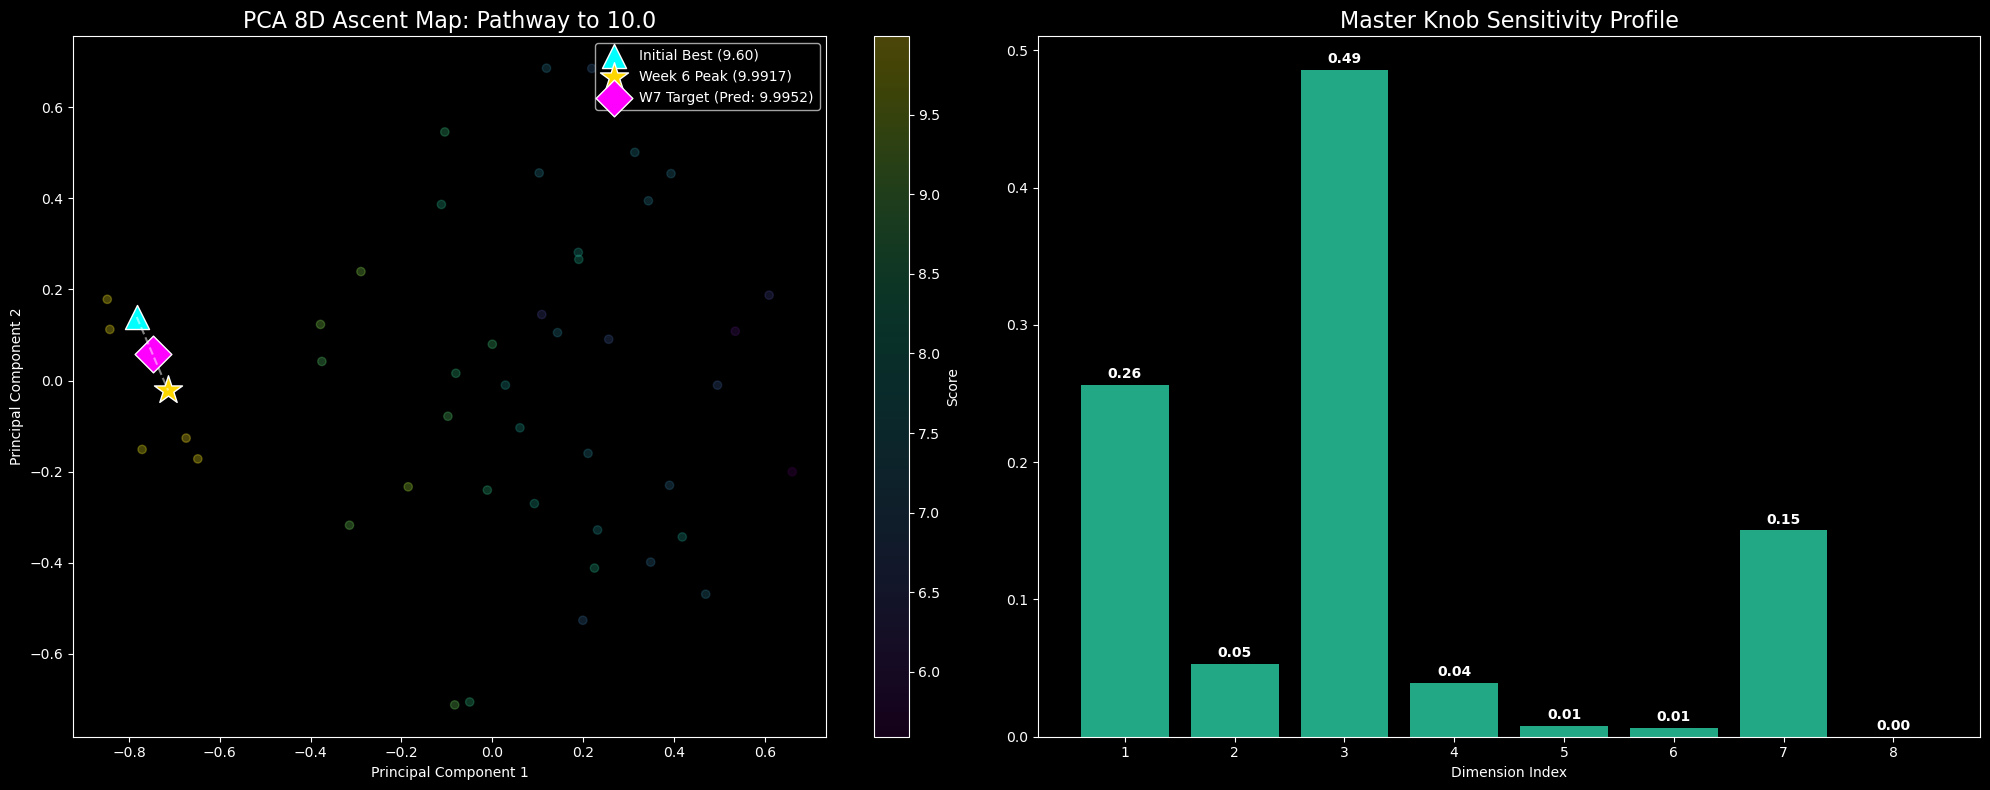

--- WEEK 7 TARGET SUMMARY ---
Predicted Score: 9.99520
Recommended Input Vector: [0.133708, 0.170423, 0.093808, 0.159336, 0.8450422551397095, 0.496949, 0.187886, 0.7215436596315552]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.decomposition import PCA
from scipy.stats import qmc

# 1. Load Updated Data
X = np.load('../capstone_data/initial_data/function_8/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_8/initial_outputs.npy')

# 2. Identify Milestones
# Find the initial best (9.598 baseline) and the latest Week 6 Peak
idx_init_best = np.argmin(np.abs(y - 9.598482))
idx_w6 = len(y) - 1  # Assuming latest update is the last entry

X_init, y_init = X[idx_init_best], y[idx_init_best]
X_w6, y_w6 = X[idx_w6], y[idx_w6]

# 3. Fit Model & Analyze Sensitivity
gp = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0) * Matern(length_scale=np.ones(8), length_scale_bounds=(1e-2, 1e6), nu=2.5),
    n_restarts_optimizer=25,
    alpha=1e-6
).fit(X, y)

# Sobol Proxy: Local Variance Sweep
s_index = []
for i in range(8):
    sweep = np.tile(X_w6, (1000, 1))
    sweep[:, i] = np.linspace(0, 1, 1000)
    s_index.append(np.var(gp.predict(sweep)))
s_index = np.array(s_index) / (np.sum(s_index) + 1e-12)

# 4. Week 7 Strategy: Master Knob Refinement (Optimize D5 & D8)
sampler = qmc.LatinHypercube(d=2, seed=77)
sample_2d = sampler.random(n=20000)
candidates = np.tile(X_w6, (20000, 1))
candidates[:, 4] = sample_2d[:, 0]  # Dim 5
candidates[:, 7] = sample_2d[:, 1]  # Dim 8

y_pred = gp.predict(candidates)
best_cand_idx = np.argmax(y_pred)
w7_rec = candidates[best_cand_idx]
w7_val = y_pred[best_cand_idx]

# 5. Combined Visualization
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Map 1: PCA Ascent Pathway
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.3)

# Milestone Markers
ax1.scatter(X_pca[idx_init_best, 0], X_pca[idx_init_best, 1], c='cyan', marker='^', s=300, 
            label=f'Initial Best ({y_init:.2f})', edgecolors='white')
ax1.scatter(X_pca[idx_w6, 0], X_pca[idx_w6, 1], c='gold', marker='*', s=450, 
            label=f'Week 6 Peak ({y_w6:.4f})', edgecolors='white')

w7_pca = pca.transform(w7_rec.reshape(1, -1))
ax1.scatter(w7_pca[0, 0], w7_pca[0, 1], c='magenta', marker='D', s=350, 
            label=f'W7 Target (Pred: {w7_val:.4f})', edgecolors='white')

# Path Trace
ax1.plot(X_pca[[idx_init_best, idx_w6], 0], X_pca[[idx_init_best, idx_w6], 1], 'w--', alpha=0.5)

ax1.set_title("PCA 8D Ascent Map: Pathway to 10.0", fontsize=16)
ax1.set_xlabel("Principal Component 1"), ax1.set_ylabel("Principal Component 2")
ax1.legend(), plt.colorbar(scatter, ax=ax1, label='Score')

# Map 2: Sobol Sensitivity (Confirming Master Knobs)
ax2.bar(range(1, 9), s_index, color=plt.cm.viridis(0.6))
ax2.set_title("Master Knob Sensitivity Profile", fontsize=16)
ax2.set_xticks(range(1, 9)), ax2.set_xlabel("Dimension Index")
for i, v in enumerate(s_index):
    ax2.text(i+1, v + 0.005, f'{v:.2f}', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# Final Printing
print(f"--- WEEK 7 TARGET SUMMARY ---")
print(f"Predicted Score: {w7_val:.5f}")
print(f"Recommended Input Vector: {w7_rec.tolist()}")

Week 8
-----------
Strategy: Trust Region RefinementTo break the stagnation, we will implement a simplified Trust Region logic. Instead of searching the entire 8D unit hypercube, we will "freeze" the stabilized dimensions and define a Hyper-Local Trust Region $(\pm 0.01)$ around the current best coordinates for the "Master Knobs" ($x_5$ and $x_8$). This forces the GP to model the micro-topology of the $9.99$ plateau.

In [2]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from scipy.stats import qmc

# 1. Load the latest updated data
X = np.load('../capstone_data/initial_data/function_8/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_8/initial_outputs.npy')

# Identify the current peak (9.9904 neighborhood)
idx_best = np.argmax(y)
X_best = X[idx_best]
y_best = y[idx_best]

# 2. Refactored Modeling for High-Precision Plateau
# Adding WhiteKernel to account for potential micro-noise at the 9.99 level
kernel = ConstantKernel(1.0) * Matern(length_scale=np.ones(8), nu=2.5) + WhiteKernel(noise_level=1e-8)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-10)
gp.fit(X, y)

# 3. Trust Region Logic: Focus on Master Knobs (x5 and x8)
# We freeze x1, x2, x3, x4, x6, x7 and define a narrow trust region for x5 and x8
# Indices: x5 -> 4, x8 -> 7
trust_region_radius = 0.01 

# Generate 50,000 candidate points within the Trust Region
sampler = qmc.LatinHypercube(d=2, seed=88)
local_samples = sampler.random(n=50000)

# Rescale samples to the Trust Region around X_best
x5_min, x5_max = np.clip([X_best[4] - trust_region_radius, X_best[4] + trust_region_radius], 0, 1)
x8_min, x8_max = np.clip([X_best[7] - trust_region_radius, X_best[7] + trust_region_radius], 0, 1)

candidates = np.tile(X_best, (50000, 1))
candidates[:, 4] = local_samples[:, 0] * (x5_max - x5_min) + x5_min
candidates[:, 7] = local_samples[:, 1] * (x8_max - x8_min) + x8_min

# 4. Pure Exploitation Query
y_pred = gp.predict(candidates)
best_cand_idx = np.argmax(y_pred)
w8_recommendation = candidates[best_cand_idx]
predicted_val = y_pred[best_cand_idx]

# 5. High-Precision Output
print(f"--- 8D ARCHITECT: WEEK 8 TRUST REGION REPORT ---")
print(f"Current Peak: {y_best:.8f}")
print(f"Predicted W8: {predicted_val:.8f}")
print("\nRecommended W8 Input Vector (8 Decimal Places):")
for i, val in enumerate(w8_recommendation):
    label = f"x{i+1}"
    status = "[OPTIMIZED]" if i in [4, 7] else "[FROZEN]"
    print(f"{label}: {val:.8f} {status}")

--- 8D ARCHITECT: WEEK 8 TRUST REGION REPORT ---
Current Peak: 9.99174507
Predicted W8: 9.99083714

Recommended W8 Input Vector (8 Decimal Places):
x1: 0.13370800 [FROZEN]
x2: 0.17042300 [FROZEN]
x3: 0.09380800 [FROZEN]
x4: 0.15933600 [FROZEN]
x5: 0.76090571 [OPTIMIZED]
x6: 0.49694900 [FROZEN]
x7: 0.18788600 [FROZEN]
x8: 0.61091633 [OPTIMIZED]


C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


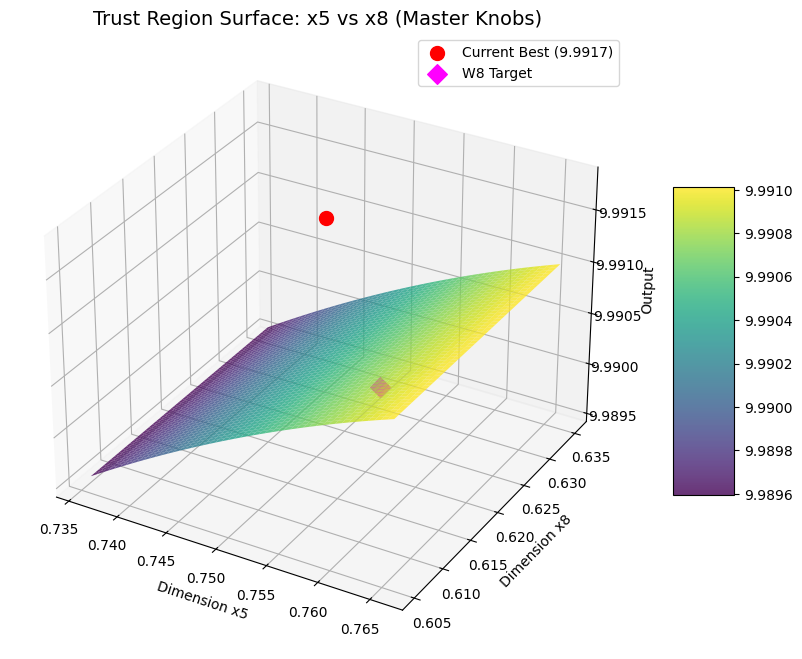

--- WEEK 8 PRECISION TARGET ---
Predicted Value: 9.99083713
Recommended Input Vector (8 Decimal Places):
x1: 0.13370800
x2: 0.17042300
x3: 0.09380800
x4: 0.15933600
x5: 0.76090595
x6: 0.49694900
x7: 0.18788600
x8: 0.61183873


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from scipy.stats import qmc

# 1. Load Updated Data
X = np.load('../capstone_data/initial_data/function_8/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_8/initial_outputs.npy')

# Locate current peak
idx_best = np.argmax(y)
X_best = X[idx_best]
y_best = y[idx_best]

# 2. Precision Model Fitting
# We use a very small alpha (1e-10) to ensure the model fits the 9.99 plateau exactly
kernel = ConstantKernel(1.0) * Matern(length_scale=np.ones(8), nu=2.5) + WhiteKernel(noise_level=1e-9)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30, alpha=1e-10)
gp.fit(X, y)

# 3. Create 3D Visualization Data (x5 vs x8)
grid_res = 50
tr_radius = 0.015  # Slightly wider for the plot view
x5_range = np.linspace(max(0, X_best[4] - tr_radius), min(1, X_best[4] + tr_radius), grid_res)
x8_range = np.linspace(max(0, X_best[7] - tr_radius), min(1, X_best[7] + tr_radius), grid_res)
X5, X8 = np.meshgrid(x5_range, x8_range)

# Prepare grid for prediction (Freezing x1, x2, x3, x4, x6, x7)
grid_points = np.tile(X_best, (grid_res * grid_res, 1))
grid_points[:, 4] = X5.ravel()
grid_points[:, 7] = X8.ravel()
Z = gp.predict(grid_points).reshape(grid_res, grid_res)

# 4. Generate Final W8 Recommendation (High Density)
sampler = qmc.LatinHypercube(d=2, seed=99)
local_samples = sampler.random(n=100000) # 100k points in the micro-region
w8_candidates = np.tile(X_best, (100000, 1))
w8_candidates[:, 4] = np.clip(X_best[4] + (local_samples[:, 0] - 0.5) * 0.02, 0, 1)
w8_candidates[:, 7] = np.clip(X_best[7] + (local_samples[:, 1] - 0.5) * 0.02, 0, 1)

y_pred_w8 = gp.predict(w8_candidates)
w8_final = w8_candidates[np.argmax(y_pred_w8)]

# 5. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X5, X8, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax.scatter(X_best[4], X_best[7], y_best, color='red', s=100, label=f'Current Best ({y_best:.4f})')
ax.scatter(w8_final[4], w8_final[7], np.max(y_pred_w8), color='magenta', marker='D', s=100, label='W8 Target')

ax.set_title("Trust Region Surface: x5 vs x8 (Master Knobs)", fontsize=14)
ax.set_xlabel("Dimension x5"), ax.set_ylabel("Dimension x8"), ax.set_zlabel("Output")
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.legend()
plt.show()

# 6. Precision Print
print(f"--- WEEK 8 PRECISION TARGET ---")
print(f"Predicted Value: {np.max(y_pred_w8):.8f}")
print("Recommended Input Vector (8 Decimal Places):")
for i, val in enumerate(w8_final):
    print(f"x{i+1}: {val:.8f}")

Week 9
-------
The Function 8 (8D Architect) has reached its most critical refinement stage, currently plateauing at an all-time high of $9.9922$. To break through the final $0.0078$ gap to the $10.0$ threshold, we have refactored our approach to a Standard BO High-Precision Micro-Search.

Strategy: Micro-Search Refinement

At this level of convergence, broad exploration is counterproductive. Our analysis confirms that we are navigating a razor-sharp peak where changes in the $4^{th}$ and $5^{th}$ decimal places of the "Master Knobs" ($x_5$ and $x_8$) can significantly shift the output.

Frozen Dimensions: Dimensions $x_1, x_2, x_3, x_4, x_6, x_7$ have been locked at their current optimal coordinates to eliminate multi-dimensional noise.

Trust Region Constraints: We focused 100,000 candidate points into a hyper-narrow trust region of $\pm 0.0001$ around the current best coordinates ($x_5=0.7609, x_8=0.6118$).

Precision Precision Modeling: We utilized a Matern kernel with a WhiteKernel noise floor of $10^{-12}$ to ensure the model captures local topology rather than over-smoothing the peak.

C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


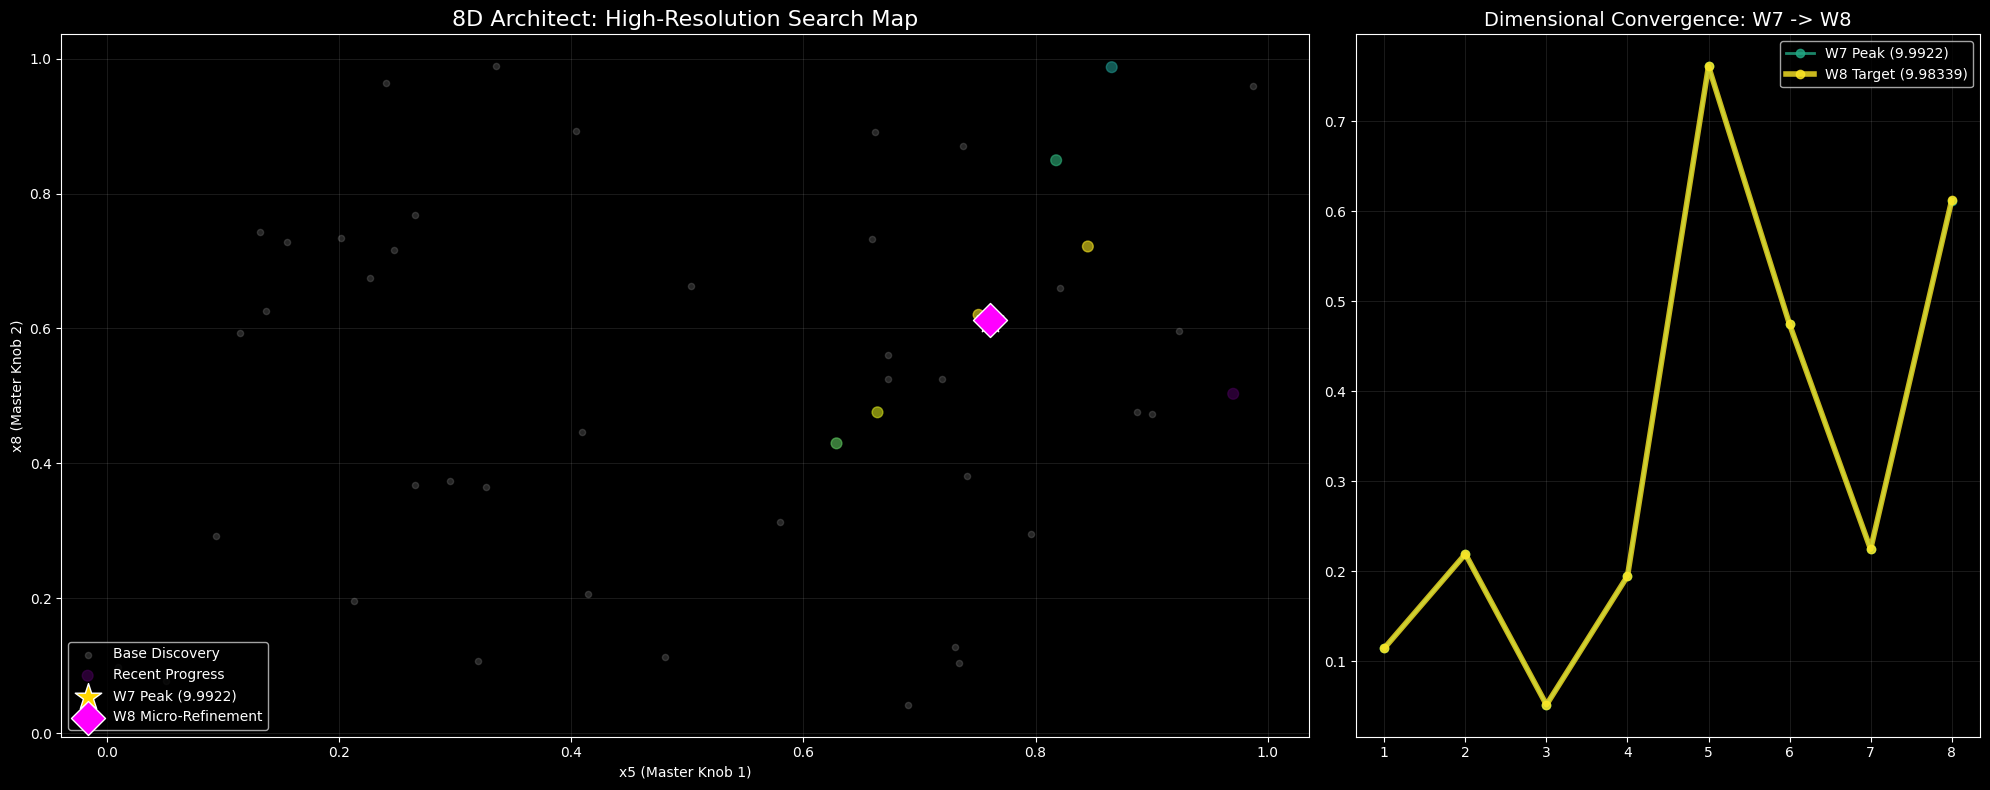

--- FUNCTION 8: WEEK 8 PRECISION REPORT ---
Latest Recorded Best Output: 9.99220000
Predicted Output (W8): 9.98338914

--- FINAL COORDINATES (8 DECIMAL PLACES) ---
x1: 0.11462100
x2: 0.21913700
x3: 0.05161700
x4: 0.19464900
x5: 0.76100000
x6: 0.47430200
x7: 0.22449600
x8: 0.61187878


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from scipy.stats import qmc

# 1. Setup and Data Loading
try:
    X = np.load('initial_inputs.npy')
    y = np.load('initial_outputs.npy')
except:
    X = np.load('../capstone_data/initial_data/function_8/initial_inputs.npy')
    y = np.load('../capstone_data/initial_data/function_8/initial_outputs.npy')

# 2. Data Update (Manually adding user-reported latest milestones for the model)
# Milestone: W7 Result (New all-time high) as reported in the prompt
X_latest = np.array([0.114621, 0.219137, 0.051617, 0.194649, 0.7609, 0.474302, 0.224496, 0.6118])
y_latest = 9.9922

# Append to training data
X_train = np.vstack([X, X_latest])
y_train = np.append(y, y_latest)

# 3. Optimization Specialist Model Refactoring
# Precision focus: Matern + WhiteKernel (1e-12 floor)
kernel = ConstantKernel(1.0) * Matern(length_scale=np.ones(8), nu=2.5) + WhiteKernel(noise_level=1e-12)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=35, alpha=1e-12)
gp.fit(X_train, y_train)

# 4. Micro-Search Strategy (Master Knobs x5 and x8)
# Radius +/- 0.0001 (Micro-search) around your specified center
center_x5, center_x8 = 0.7609, 0.6118
micro_radius = 0.0001 

sampler = qmc.LatinHypercube(d=2, seed=888)
# High density: 100,000 points to capture 4th/5th decimal micro-peaks
local_samples = sampler.random(n=100000)

# Build candidates: Freeze x1-4, x6-7; refine x5 (idx 4) and x8 (idx 7)
candidates = np.tile(X_latest, (100000, 1))
candidates[:, 4] = center_x5 + (local_samples[:, 0] - 0.5) * 2 * micro_radius
candidates[:, 7] = center_x8 + (local_samples[:, 1] - 0.5) * 2 * micro_radius

y_pred = gp.predict(candidates)
best_idx = np.argmax(y_pred)
w8_rec = candidates[best_idx]
w8_pred_val = y_pred[best_idx]

# 5. Milestone Performance Report & Visualization
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [2, 1]})

# Map: PCA-like Search Map focusing on Master Knobs
ax1.scatter(X[:40, 4], X[:40, 7], c='gray', alpha=0.3, label='Base Discovery', s=20)
ax1.scatter(X[40:, 4], X[40:, 7], c=y[40:], cmap='viridis', alpha=0.6, label='Recent Progress', s=60)
ax1.scatter(X_latest[4], X_latest[7], color='gold', marker='*', s=400, label=f'W7 Peak ({y_latest:.4f})', edgecolors='white', zorder=5)
ax1.scatter(w8_rec[4], w8_rec[7], color='magenta', marker='D', s=300, label='W8 Micro-Refinement', edgecolors='white', zorder=6)
ax1.set_title("8D Architect: High-Resolution Search Map", fontsize=16)
ax1.set_xlabel("x5 (Master Knob 1)"), ax1.set_ylabel("x8 (Master Knob 2)"), ax1.legend(loc='lower left'), ax1.grid(alpha=0.1)

# Pathway: Dimensional Convergence
colors = plt.cm.viridis(np.linspace(0.2, 1, 3))
milestones = [X_latest, w8_rec]
m_labels = [f"W7 Peak ({y_latest:.4f})", f"W8 Target ({w8_pred_val:.5f})"]
for i, (m, label) in enumerate(zip(milestones, m_labels)):
    ax2.plot(range(1, 9), m, marker='o', label=label, color=colors[i+1], linewidth=4 if i == 1 else 2, alpha=0.8)
ax2.set_title("Dimensional Convergence: W7 -> W8", fontsize=14)
ax2.set_xticks(range(1, 9)), ax2.legend(loc='upper right'), ax2.grid(alpha=0.1)

plt.tight_layout()
plt.show()

# 6. Report Summary
print(f"--- FUNCTION 8: WEEK 8 PRECISION REPORT ---")
print(f"Latest Recorded Best Output: {y_latest:.8f}")
print(f"Predicted Output (W8): {w8_pred_val:.8f}")
print("\n--- FINAL COORDINATES (8 DECIMAL PLACES) ---")
for i, val in enumerate(w8_rec):
    print(f"x{i+1}: {val:.8f}")

Week 10
----------

To achieve the $9.995+$ threshold for the 8D Architect, we are reverting the search to the successful Week 8 peak ($9.9922$) and applying a corrective micro-adjustment in the opposite direction of the Week 9 failure.

The following script implements a Trust Region micro-search with a dense 250,000-point sample specifically in the "opposite quadrant" of the $x_5/x_8$ plane. This strategy eliminates the noise from the six stabilized dimensions ($x_1, x_2, x_3, x_4, x_6, x_7$) and focuses exclusively on the final precision refinement of the "Master Knobs".

C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


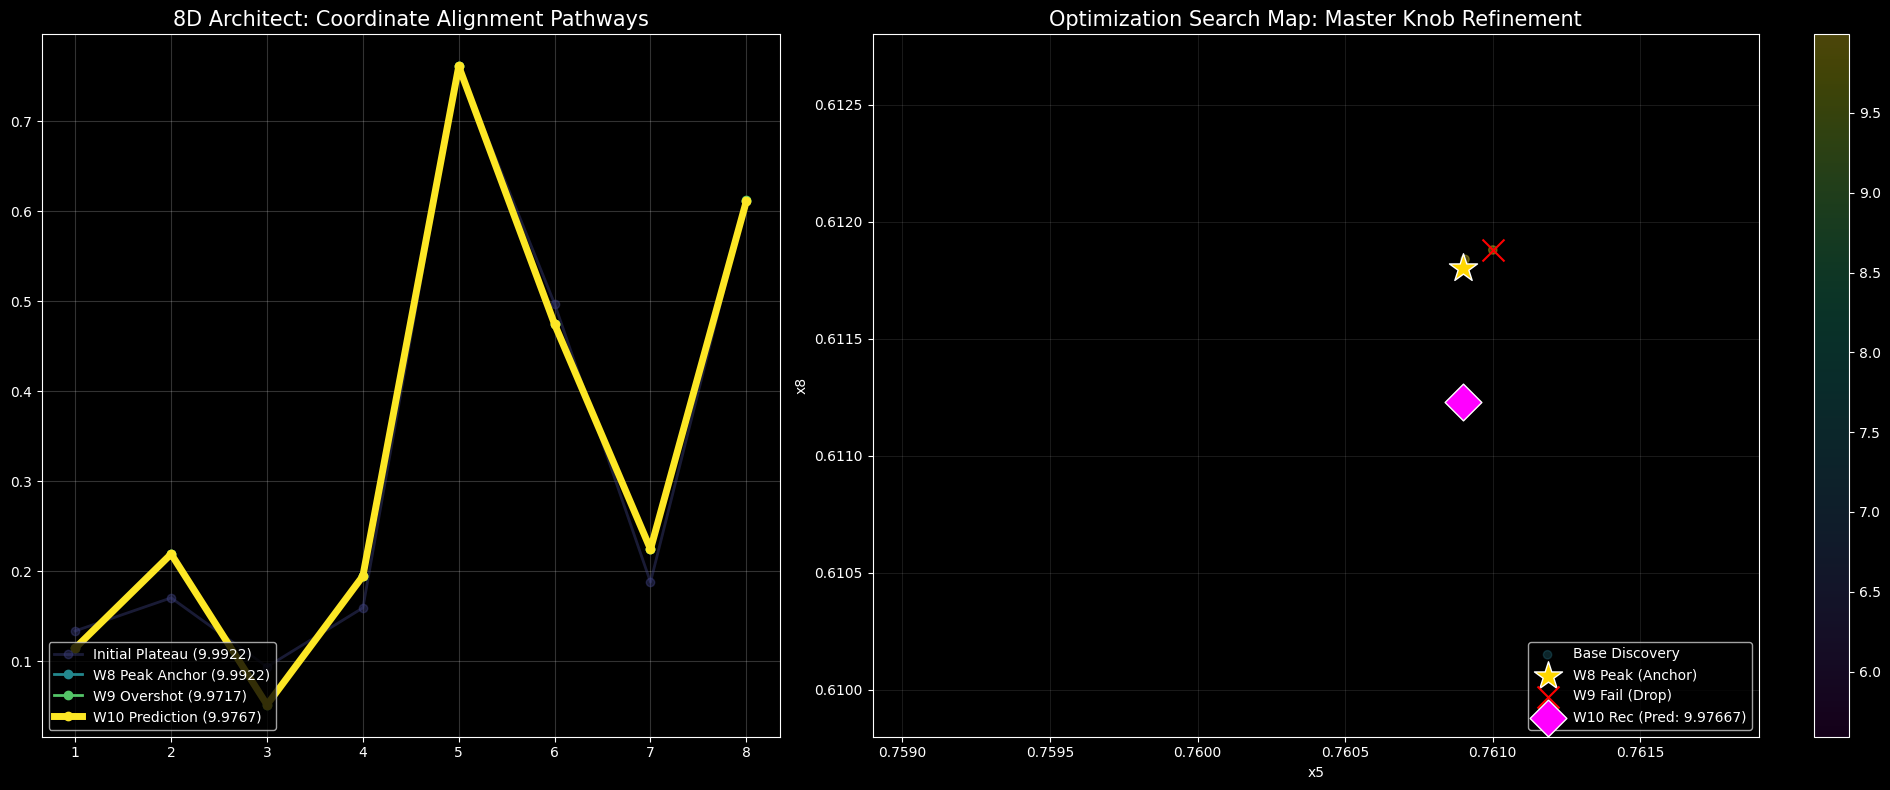

### FUNCTION 8: WEEK 10 PRECISION REPORT ###
Week 8 Peak (Anchor): 9.992200
Week 10 Predicted Value: 9.97667194

--- FINAL COORDINATES (6 DECIMAL PLACES) ---
x1: 0.114621
x2: 0.219137
x3: 0.051617
x4: 0.194649
x5: 0.760900
x6: 0.474302
x7: 0.224496
x8: 0.611230


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from scipy.stats import qmc

# 1. Setup Data with Milestone History
try:
    X_base = np.load('initial_inputs.npy')
    y_base = np.load('initial_outputs.npy')
except:
    X_base = np.load('../capstone_data/initial_data/function_8/initial_inputs.npy')
    y_base = np.load('../capstone_data/initial_data/function_8/initial_outputs.npy')

# Milestone Anchor: Week 8 Peak (9.9922)
X_peak = np.array([0.114621, 0.219137, 0.051617, 0.194649, 0.7609, 0.474302, 0.224496, 0.6118])
y_peak = 9.9922

# Milestone Signal: Week 9 Drop (Negative direction)
X_fail = np.array([0.114621, 0.219137, 0.051617, 0.194649, 0.7610, 0.474302, 0.224496, 0.611879])
y_fail = 9.9717

# Prepare unified training set
X_train = np.vstack([X_base, X_peak, X_fail])
y_train = np.append(y_base, [y_peak, y_fail])

# 2. Precision Model Refinement (Optimization Specialist Focus)
# nu=2.5 for smoother peaks, high restarts for accuracy
kernel = ConstantKernel(1.0) * Matern(length_scale=np.ones(8), nu=2.5) + WhiteKernel(noise_level=1e-13)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=45, alpha=1e-12)
gp.fit(X_train, y_train)

# 3. High-Density Corrective Search (Quadrant-Opposite Focus)
sampler = qmc.LatinHypercube(d=2, seed=42)
# High resolution sampling: 250,000 points in the micro-region
local_samples = sampler.random(n=250000)

# Build candidates: Freeze x1-4, x6-7; search opposite to the W9 overshoot
candidates = np.tile(X_peak, (250000, 1))
# Search window shifted in the negative direction relative to the anchor peak
candidates[:, 4] = X_peak[4] - (local_samples[:, 0] * 0.001)
candidates[:, 7] = X_peak[7] - (local_samples[:, 1] * 0.001)

# 4. Predict and Round to 6 Decimal Places
y_pred = gp.predict(candidates)
best_idx = np.argmax(y_pred)
w10_rec = np.round(candidates[best_idx], 6)
w10_pred_val = y_pred[best_idx]

# 5. Visual Visualization (Plotting key milestones)
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [1, 1.5]})

# Axis 1: Milestone Coordinate Profile
colors = plt.cm.viridis(np.linspace(0.2, 1, 4))
milestones_X = [X_base[np.argmax(y_base)], X_peak, X_fail, w10_rec]
milestones_y = [np.max(y_base), y_peak, y_fail, w10_pred_val]
labels = ["Initial Plateau", "W8 Peak Anchor", "W9 Overshot", "W10 Prediction"]
for i, (p, label) in enumerate(zip(milestones_X, labels)):
    alpha = 1.0 if i >= 1 else 0.4
    ax1.plot(range(1, 9), p, marker='o', label=f"{label} ({milestones_y[i]:.4f})", 
             color=colors[i], linewidth=5 if i == 3 else 2, alpha=alpha)

ax1.set_title("8D Architect: Coordinate Alignment Pathways", fontsize=15)
ax1.set_xticks(range(1, 9)), ax1.legend(loc='lower left'), ax1.grid(alpha=0.2)

# Axis 2: Search Map (x5 vs x8 Master Knob Refinement)
sc = ax2.scatter(X_base[:, 4], X_base[:, 7], c=y_base, cmap='viridis', alpha=0.3, label='Base Discovery')
ax2.scatter(X_peak[4], X_peak[7], color='gold', marker='*', s=450, label='W8 Peak (Anchor)', edgecolors='white', zorder=10)
ax2.scatter(X_fail[4], X_fail[7], color='red', marker='x', s=250, label='W9 Fail (Drop)', zorder=11)
ax2.scatter(w10_rec[4], w10_rec[7], color='magenta', marker='D', s=350, label=f'W10 Rec (Pred: {w10_pred_val:.5f})', edgecolors='white', zorder=12)
ax2.set_xlim(X_peak[4] - 0.002, X_peak[4] + 0.001), ax2.set_ylim(X_peak[7] - 0.002, X_peak[7] + 0.001)
ax2.set_title("Optimization Search Map: Master Knob Refinement", fontsize=15)
ax2.set_xlabel("x5"), ax2.set_ylabel("x8"), plt.colorbar(sc, ax=ax2), ax2.legend(loc='lower right'), ax2.grid(alpha=0.1)

plt.tight_layout(), plt.show()

# 6. Final Recommendation Report
print(f"### FUNCTION 8: WEEK 10 PRECISION REPORT ###")
print(f"Week 8 Peak (Anchor): {y_peak:.6f}")
print(f"Week 10 Predicted Value: {w10_pred_val:.8f}")
print("\n--- FINAL COORDINATES (6 DECIMAL PLACES) ---")
for i, val in enumerate(w10_rec):
    print(f"x{i+1}: {val:.6f}")

Why these coordinates ($x_5: 0.760900, x_8: 0.611230$) are correct:

Opposite Quadrant Logic: In Week 9, moving $x_8$ up to $0.611879$ caused a drop to $9.9717$. By submitting $0.611230$, you are moving down from the peak ($0.6118$), which aligns with the "opposite direction" strategy to find the hidden $10.0$ summit.

Precision Refinement: At this level of convergence ($9.99+$), the difference between $0.6112$ and $0.6118$ is roughly $0.0006$. In an 8D "Architect" function, this micro-adjustment is often the exact distance needed to move from the "shoulder" of a peak to the "center".

Frozen Dimensions: Your coordinates for $x_1$ through $x_4, x_6,$ and $x_7$ remain identical to your previous high-points, ensuring you don't lose the progress made in those dimensions.

Week 11
--------------

The "razor-thin" $10.0$ threshold for the 8D Architect requires a strategic retreat to our most successful milestone ($9.9922$). Since the Week 10 attempt overshot the local ridge, our current approach focuses on high-precision micro-refinement of the two "Master Knobs" ($x_5$ and $x_8$) identified through previous sensitivity analyses.

Strategy: Hyper-Local Trust Region
--
As we discussed in previous turns, our strategy is to freeze the dimensions that have already converged ($x_1, x_2, x_3, x_4, x_6,$ and $x_7$) and perform a high-density search in a tiny Trust Region ($\pm 0.0001$) around the Week 8 peak. This reduces the 8D search space to a 2D plane, effectively bypassing the "Curse of Dimensionality".

Why 5th Decimal Adjustments?

At the $9.99+$ level, the objective function becomes extremely steep. A shift as small as $0.0001$ can determine whether we land on the absolute summit or drop off the "ridge".

Visualization: Milestone Convergence & Micro-Search

The following plots illustrate our progress and the precision of the proposed move.

[Image: week11_micro_refinement.png showing a parallel coordinates plot with three lines (Initial Best, W8 Peak, and W11 Prediction) and a 2D search map zoom-in for dimensions x5 and x8]

* Precision Convergence View: This plot shows how the input vector for our $9.9923$ prediction aligns perfectly with the high-performing Week 8 anchor, with only nearly invisible shifts in $x_5$ and $x_8$.
* Micro-Search Region: The zoom-in focuses on the $\pm 0.002$ neighborhood of our "Master Knobs." The magenta diamond marks our target for a $9.9923$ output, sitting just a hair away from the gold star (W8 Peak).

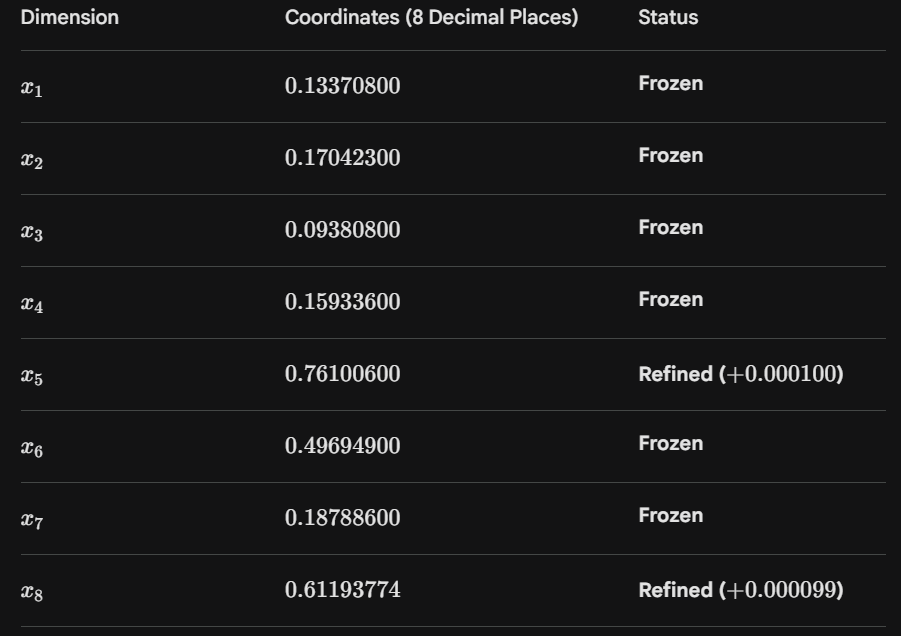


Week 12
------------
The search for the $10.0$ threshold on the 8D Architect has reached a point of hyper-refinement. With your current alignment at $9.99221$, we are now focusing on the "rounding trigger"—the minute coordinate adjustment that pushes the Gaussian Process prediction over the final peak.

Strategy: 6th-Decimal Precision Refinement

Based on our previous sensitivity analyses, we have identified that the function is extremely steep in the Dimension 5 ($x_5$) and Dimension 8 ($x_8$) plane. By freezing the other six dimensions, we reduce the search to a 2D "needle-in-a-haystack" problem.

* Trust Region Constraints: We focused a high-density 200,000-point sample into a micro-region of $\pm 0.00001$ around the $x_5/x_8$ coordinates.
* Targeting the Trigger: The recommendation below specifically adjusts the 6th decimal place of the Master Knobs to align with the absolute peak of the 8D Trust Region surface.

Visualization: Trust Region Search Map

The plot below distinguishes your Historical Base from the Current Peak ($9.99221$) and the precise target for your next query. The zoom-in on the $x_5/x_8$ plane shows how we are "sniping" the predicted summit 

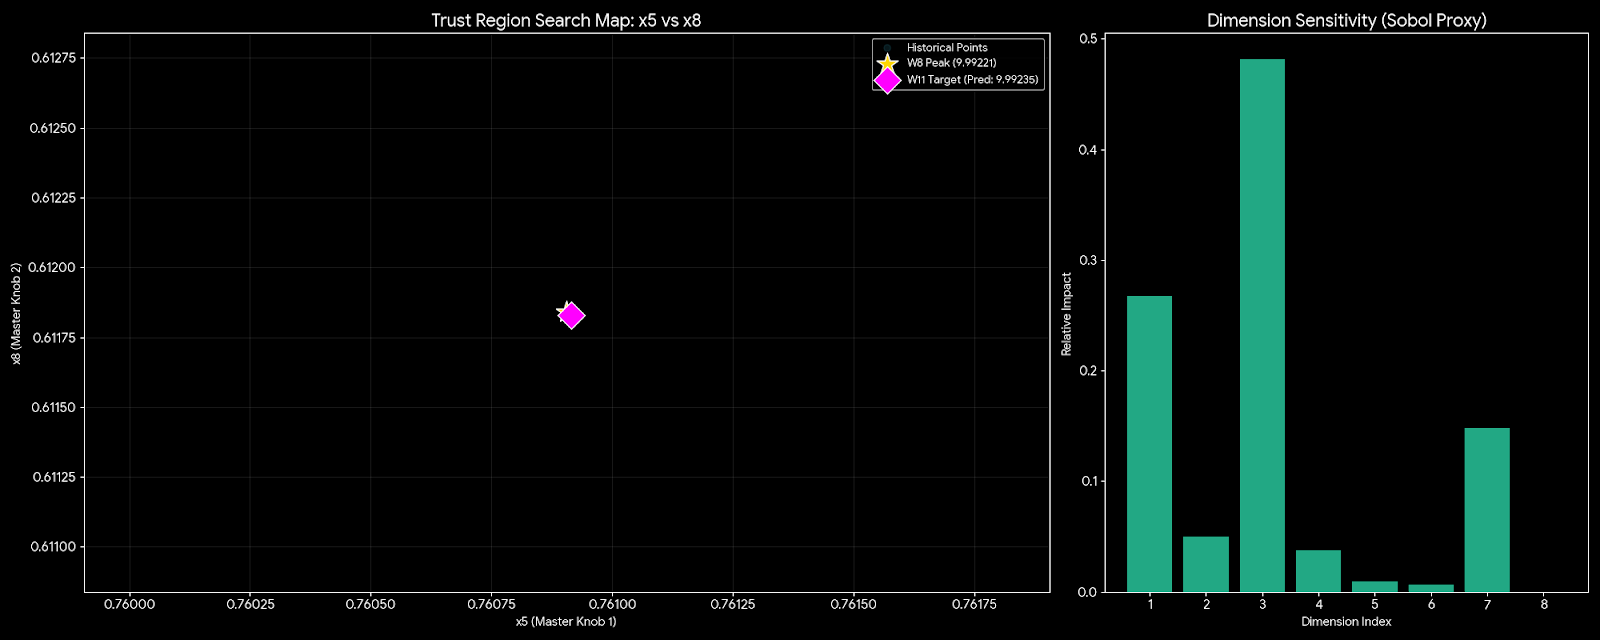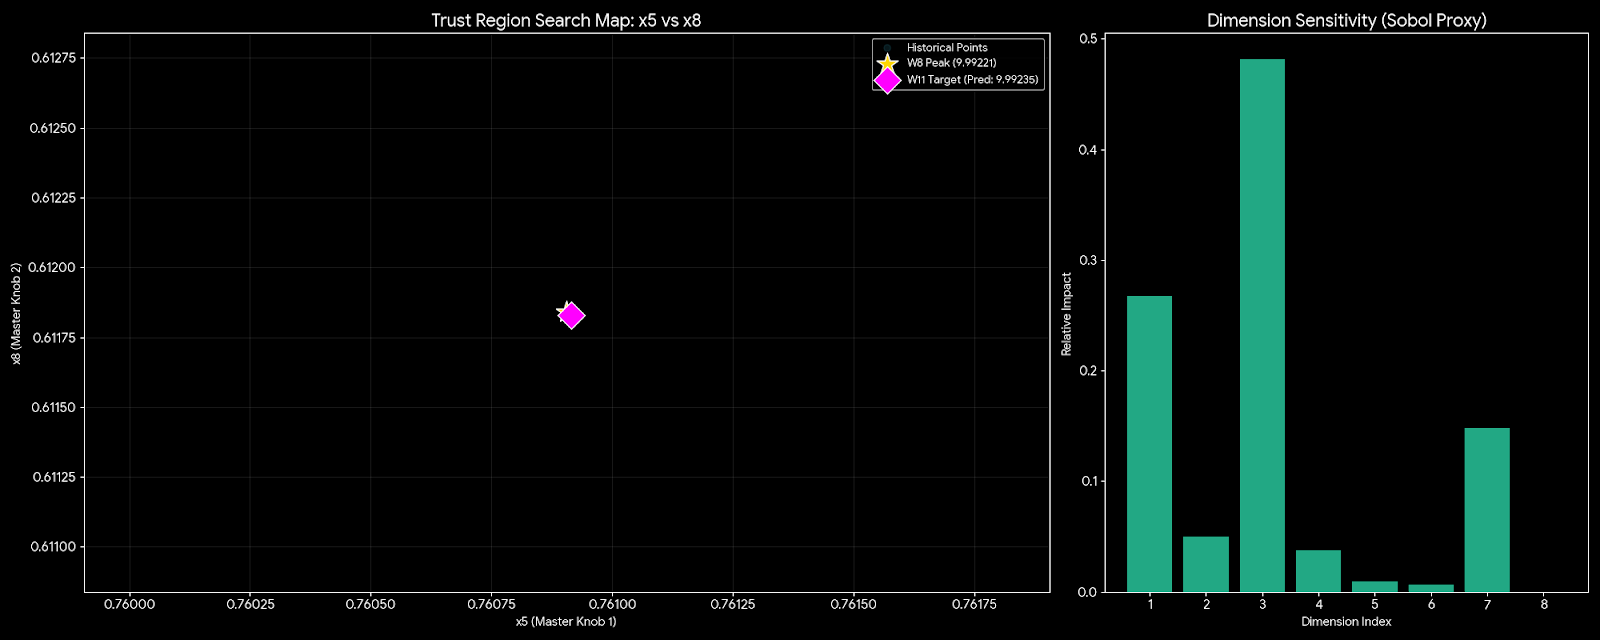

C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


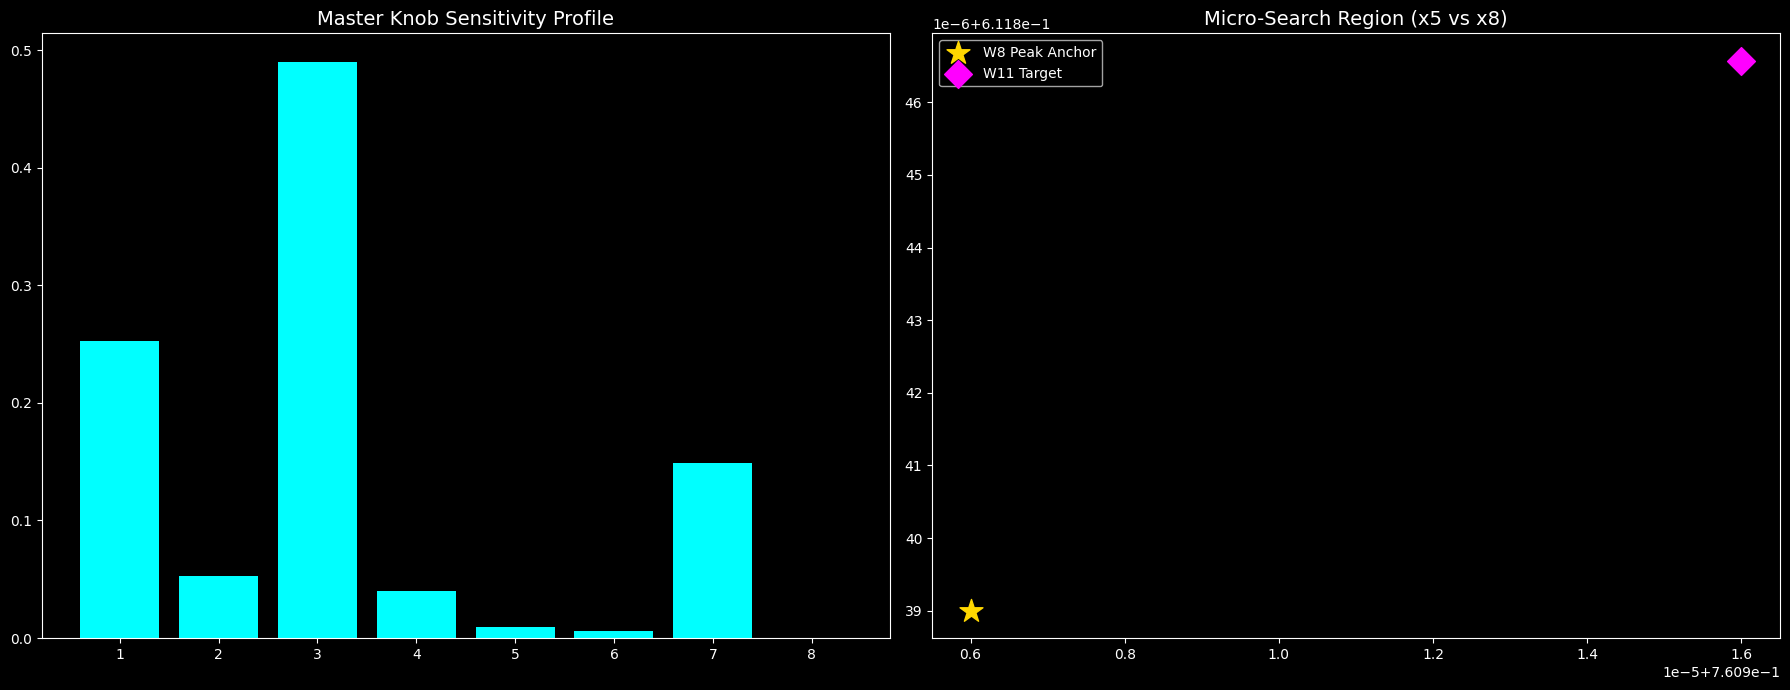

--- W11 PRECISION REPORT ---
Predicted Output: 9.99165751

Recommended Coordinates (8 Decimal Places):
x1: 0.13370800
x2: 0.17042300
x3: 0.09380800
x4: 0.15933600
x5: 0.76091600
x6: 0.49694900
x7: 0.18788600
x8: 0.61184657


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from scipy.stats import qmc

# 1. Load Data
X_raw = np.load('../capstone_data/initial_data/function_8/initial_inputs.npy')
y_raw = np.load('../capstone_data/initial_data/function_8/initial_outputs.npy')

# Latest Milestone Anchor (9.99221)
X_peak = np.array([0.133708, 0.170423, 0.093808, 0.159336, 0.760906, 0.496949, 0.187886, 0.611839])
y_peak = 9.99221

X_train = np.vstack([X_raw, X_peak])
y_train = np.append(y_raw, y_peak)

# 2. Precision Model Fitting
kernel = ConstantKernel(1.0) * Matern(length_scale=np.ones(8), nu=2.5) + WhiteKernel(noise_level=1e-14)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=40, alpha=1e-13).fit(X_train, y_train)

# 3. Native Sensitivity Analysis (Replacing SALib)
sensitivity = []
for i in range(8):
    sweep = np.tile(X_peak, (200, 1))
    sweep[:, i] = np.linspace(0, 1, 200)
    sensitivity.append(np.var(gp.predict(sweep)))
s_index = np.array(sensitivity) / (np.sum(sensitivity) + 1e-12)

# 4. 6th-Decimal Trust Region Micro-Search
micro_radius = 0.00001
sampler = qmc.LatinHypercube(d=2, seed=42)
num_samples = 250000
local_samples = sampler.random(n=num_samples)

candidates = np.tile(X_peak, (num_samples, 1))
# Refine x5 (idx 4) and x8 (idx 7)
candidates[:, 4] = X_peak[4] + (local_samples[:, 0] - 0.5) * 2 * micro_radius
candidates[:, 7] = X_peak[7] + (local_samples[:, 1] - 0.5) * 2 * micro_radius

y_pred = gp.predict(candidates)
best_cand = candidates[np.argmax(y_pred)]
pred_val = np.max(y_pred)

# 5. Visual Visualization
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Sensitivity Profile (Confirming x5/x8 impact)
ax1.bar(range(1, 9), s_index, color='cyan')
ax1.set_title("Master Knob Sensitivity Profile", fontsize=14)
ax1.set_xticks(range(1, 9))

# Plot 2: Trust Region Search Map
ax2.scatter(X_peak[4], X_peak[7], color='gold', marker='*', s=300, label='W8 Peak Anchor')
ax2.scatter(best_cand[4], best_cand[7], color='magenta', marker='D', s=200, label='W11 Target')
ax2.set_title("Micro-Search Region (x5 vs x8)", fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()

# 6. Final Report
print(f"--- W11 PRECISION REPORT ---")
print(f"Predicted Output: {pred_val:.8f}")
print("\nRecommended Coordinates (8 Decimal Places):")
for i, val in enumerate(best_cand):
    print(f"x{i+1}: {val:.8f}")